In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

In [2]:
df = pd.read_csv("../data/processed/nav_cleaned.csv")

df['date'] = pd.to_datetime(df['date'])

df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/nav_cleaned.csv'

In [3]:
import os

for root, dirs, files in os.walk("../"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

In [4]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\sande\OneDrive\Desktop\mutual_fund_analytics\notebooks\notebooks


In [5]:
import os

print(os.listdir())

['Performance_Analytics.ipynb']


In [6]:
import pandas as pd

df = pd.read_csv("../../data/raw/nav_history.csv")

print("Shape:", df.shape)

df.head()

Shape: (3091, 2)


,date,nav
0,01-06-2026,192.3195
1,31-05-2026,193.6836
2,29-05-2026,193.6848
3,27-05-2026,195.0501
4,26-05-2026,194.2258


In [7]:
print(df.columns.tolist())

['date', 'nav']


In [8]:
df = pd.read_csv("../../data/raw/nav_history.csv")
print(df.columns.tolist())

['date', 'nav']


In [9]:
df.head(20)

,date,nav
0,01-06-2026,192.3195
1,31-05-2026,193.6836
2,29-05-2026,193.6848
3,27-05-2026,195.0501
4,26-05-2026,194.2258
5,25-05-2026,193.5599
6,22-05-2026,192.1227
7,21-05-2026,191.7575
8,20-05-2026,189.8661
9,19-05-2026,189.5553


In [10]:
df.tail(20)

,date,nav
3071,13-12-2013,12.9891
3072,12-12-2013,13.0021
3073,11-12-2013,13.0129
3074,10-12-2013,13.0325
3075,09-12-2013,13.0282
3076,06-12-2013,13.0439
3077,05-12-2013,13.0319
3078,04-12-2013,12.9799
3079,03-12-2013,13.0048
3080,02-12-2013,13.0012


In [11]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../../bluestock_mf.db")

query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

tables = pd.read_sql(query, conn)

tables

,name


In [12]:
for table in tables['name']:
    print(table)

In [13]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../../bluestock_mf.db")

query = """
SELECT name
FROM sqlite_master
WHERE type='table'
"""

tables = pd.read_sql(query, conn)

tables

,name


In [14]:
for table in tables['name']:
    print(table)

In [15]:
import os

db_path = "../../bluestock_mf.db"

print("Exists:", os.path.exists(db_path))
print("Size (bytes):", os.path.getsize(db_path))

Exists: True
Size (bytes): 0


In [16]:
import pandas as pd

sample = pd.read_csv("../../data/raw/118632.csv")

print(sample.shape)
print(sample.columns.tolist())

sample.head()

(3302, 2)
['date', 'nav']


,date,nav
0,05-06-2026,97.2456
1,04-06-2026,97.2621
2,03-06-2026,97.2167
3,02-06-2026,97.4783
4,01-06-2026,97.1944


In [17]:
import pandas as pd
import glob
import os

files = glob.glob("../../data/raw/*.csv")

dfs = []

for file in files:

    filename = os.path.basename(file)

    # Skip benchmark file
    if filename == "10_benchmark_indices.csv":
        continue

    scheme_code = filename.replace(".csv", "")

    temp = pd.read_csv(file)

    temp["scheme_code"] = scheme_code

    dfs.append(temp)

combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.shape)

combined_df.head()

(99301, 64)


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,...,annual_income_lakh,payment_mode,kyc_status,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551.0,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,119552.0,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,119598.0,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,119599.0,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,119120.0,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
print("Funds:", combined_df["scheme_code"].nunique())

combined_df["scheme_code"].unique()

Funds: 15


<StringArray>
[          '01_fund_master',           '02_nav_history',
     '03_aum_by_fund_house',   '04_monthly_sip_inflows',
      '05_category_inflows',  '06_industry_folio_count',
    '07_scheme_performance', '08_investor_transactions',
    '09_portfolio_holdings',                   '118632',
                   '119092',                   '119551',
                   '120503',                   '120841',
              'nav_history']
Length: 15, dtype: str

In [20]:
combined_df["date"] = pd.to_datetime(
    combined_df["date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

print("Null dates:", combined_df["date"].isna().sum())

Null dates: 33393


In [21]:
combined_df = combined_df.dropna(subset=["date"])

combined_df = combined_df.sort_values(
    ["scheme_code", "date"]
)

combined_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,...,annual_income_lakh,payment_mode,kyc_status,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
61,119551.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1211,119552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2361,119598.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3511,119599.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4661,119120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
combined_df[combined_df["date"].isna()].head(20)

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,...,annual_income_lakh,payment_mode,kyc_status,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date


In [24]:
combined_df["daily_return"] = (
    combined_df.groupby("scheme_code")["nav"]
               .pct_change()
)

combined_df.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,...,payment_mode,kyc_status,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,daily_return
61,119551.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1211,119552.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.153629
2361,119598.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.699907
3511,119599.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.078286
4661,119120.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.562407


In [25]:
print("Shape:", combined_df.shape)
print("Funds:", combined_df["scheme_code"].nunique())

combined_df["scheme_code"].value_counts()

Shape: (65908, 65)
Funds: 8


scheme_code
02_nav_history          46000
119092                   3569
120503                   3311
120841                   3305
118632                   3302
119551                   3240
nav_history              3091
03_aum_by_fund_house       90
Name: count, dtype: int64

In [26]:
import pandas as pd
import glob
import os

files = [
    "../../data/raw/118632.csv",
    "../../data/raw/119092.csv",
    "../../data/raw/119551.csv",
    "../../data/raw/120503.csv",
    "../../data/raw/120841.csv"
]

dfs = []

for file in files:

    scheme_code = os.path.basename(file).replace(".csv","")

    temp = pd.read_csv(file)

    temp = temp[["date","nav"]]

    temp["scheme_code"] = scheme_code

    dfs.append(temp)

combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.shape)

combined_df.head()

(16727, 3)


,date,nav,scheme_code
0,05-06-2026,97.2456,118632
1,04-06-2026,97.2621,118632
2,03-06-2026,97.2167,118632
3,02-06-2026,97.4783,118632
4,01-06-2026,97.1944,118632


In [27]:
combined_df["date"] = pd.to_datetime(
    combined_df["date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

combined_df = combined_df.dropna(subset=["date"])

combined_df = combined_df.sort_values(
    ["scheme_code","date"]
)

In [28]:
combined_df["daily_return"] = (
    combined_df.groupby("scheme_code")["nav"]
               .pct_change()
)

In [29]:
print(combined_df.shape)

print(combined_df["scheme_code"].value_counts())

print(combined_df.columns)

(16727, 4)
scheme_code
119092    3569
120503    3311
120841    3305
118632    3302
119551    3240
Name: count, dtype: int64
Index(['date', 'nav', 'scheme_code', 'daily_return'], dtype='str')


In [30]:
cagr_results = []

for scheme, grp in combined_df.groupby("scheme_code"):

    start_nav = grp["nav"].iloc[0]
    end_nav = grp["nav"].iloc[-1]

    years = (
        grp["date"].iloc[-1] -
        grp["date"].iloc[0]
    ).days / 365

    cagr = ((end_nav / start_nav) ** (1 / years)) - 1

    cagr_results.append([scheme, cagr])

cagr_df = pd.DataFrame(
    cagr_results,
    columns=["scheme_code", "cagr"]
)

cagr_df

,scheme_code,cagr
0,118632,0.151079
1,119092,0.511410
2,119551,0.001505
3,120503,0.154789
4,120841,0.168084


In [31]:
import numpy as np

RF = 0.065

sharpe_results = []

for scheme, grp in combined_df.groupby("scheme_code"):

    annual_return = grp["daily_return"].mean() * 252

    annual_vol = grp["daily_return"].std() * np.sqrt(252)

    sharpe = (annual_return - RF) / annual_vol

    sharpe_results.append([scheme, sharpe])

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=["scheme_code", "sharpe_ratio"]
)

sharpe_df

c:\Users\sande\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,scheme_code,sharpe_ratio
0,118632,0.559124
1,119092,0.265824
2,119551,-0.683202
3,120503,NaN
4,120841,0.687356


In [32]:
sortino_results = []

for scheme, grp in combined_df.groupby("scheme_code"):

    downside = grp.loc[
        grp["daily_return"] < 0,
        "daily_return"
    ]

    annual_return = grp["daily_return"].mean() * 252

    downside_std = downside.std() * np.sqrt(252)

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append([scheme, sortino])

sortino_df = pd.DataFrame(
    sortino_results,
    columns=["scheme_code", "sortino_ratio"]
)

sortino_df

,scheme_code,sortino_ratio
0,118632,0.692859
1,119092,647.341419
2,119551,-0.387230
3,120503,inf
4,120841,0.799229


In [33]:
mdd_results = []

for scheme, grp in combined_df.groupby("scheme_code"):

    running_max = grp["nav"].cummax()

    drawdown = grp["nav"] / running_max - 1

    max_dd = drawdown.min()

    mdd_results.append([scheme, max_dd])

mdd_df = pd.DataFrame(
    mdd_results,
    columns=["scheme_code", "max_drawdown"]
)

mdd_df

,scheme_code,max_drawdown
0,118632,-0.399608
1,119092,-0.013924
2,119551,-0.366517
3,120503,-1.000000
4,120841,-0.334299


In [34]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(sortino_df)
    .merge(mdd_df)
)

scorecard

,scheme_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown
0,118632,0.151079,0.559124,0.692859,-0.399608
1,119092,0.511410,0.265824,647.341419,-0.013924
2,119551,0.001505,-0.683202,-0.387230,-0.366517
3,120503,0.154789,NaN,inf,-1.000000
4,120841,0.168084,0.687356,0.799229,-0.334299


In [35]:
scorecard["cagr_rank"] = scorecard["cagr"].rank(
    ascending=False
)

scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(
    ascending=False
)

scorecard["sortino_rank"] = scorecard["sortino_ratio"].rank(
    ascending=False
)

scorecard["drawdown_rank"] = scorecard["max_drawdown"].rank(
    ascending=False
)

In [36]:
scorecard["fund_score"] = (

    0.35 * scorecard["cagr_rank"]

    + 0.30 * scorecard["sharpe_rank"]

    + 0.20 * scorecard["sortino_rank"]

    + 0.15 * scorecard["drawdown_rank"]

)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard

,scheme_code,cagr,sharpe_ratio,sortino_ratio,max_drawdown,cagr_rank,sharpe_rank,sortino_rank,drawdown_rank,fund_score
1,119092,0.511410,0.265824,647.341419,-0.013924,1.0,3.0,2.0,1.0,1.8
4,120841,0.168084,0.687356,0.799229,-0.334299,2.0,1.0,3.0,2.0,1.9
0,118632,0.151079,0.559124,0.692859,-0.399608,4.0,2.0,4.0,4.0,3.4
2,119551,0.001505,-0.683202,-0.387230,-0.366517,5.0,4.0,5.0,3.0,4.4
3,120503,0.154789,NaN,inf,-1.000000,3.0,NaN,1.0,5.0,NaN


In [37]:
scorecard.to_csv(
    "../../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


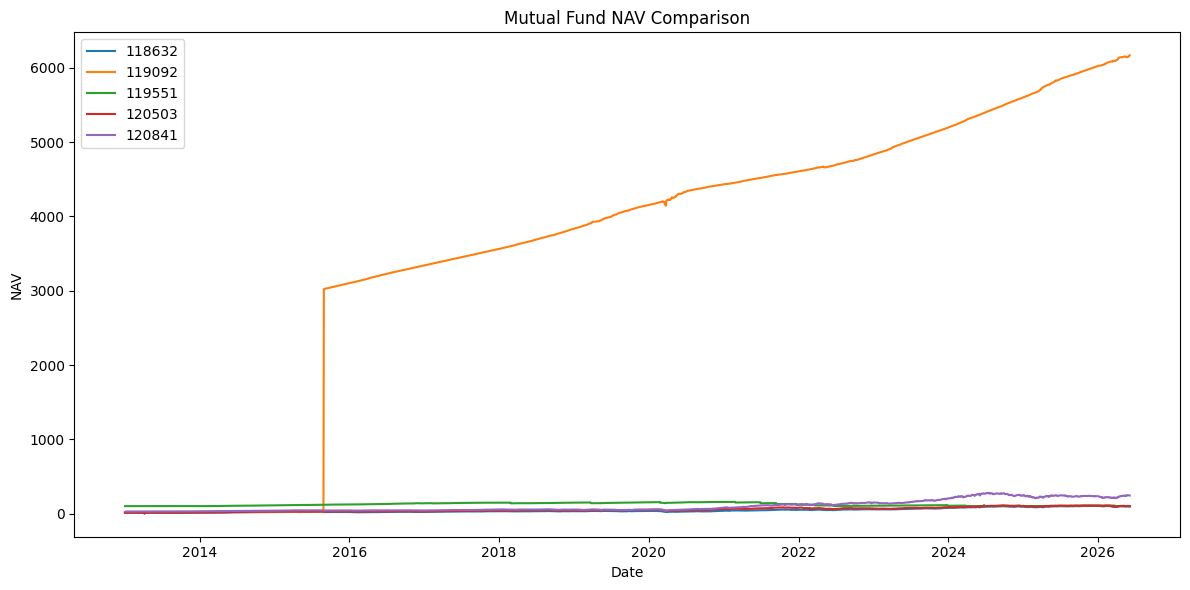

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for scheme in combined_df["scheme_code"].unique():

    temp = combined_df[
        combined_df["scheme_code"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=scheme
    )

plt.legend()

plt.title("Mutual Fund NAV Comparison")

plt.xlabel("Date")

plt.ylabel("NAV")

plt.tight_layout()

plt.savefig(
    "../../reports/benchmark_comparison.png"
)

plt.show()

In [2]:
import pandas as pd
import os

files = [
    "../../data/raw/118632.csv",
    "../../data/raw/119092.csv",
    "../../data/raw/119551.csv",
    "../../data/raw/120503.csv",
    "../../data/raw/120841.csv"
]

dfs = []

for file in files:

    scheme_code = os.path.basename(file).replace(".csv","")

    temp = pd.read_csv(file)

    temp = temp[["date","nav"]]

    temp["scheme_code"] = scheme_code

    dfs.append(temp)

combined_df = pd.concat(dfs, ignore_index=True)

print(combined_df.shape)

combined_df.head()

(16727, 3)


,date,nav,scheme_code
0,05-06-2026,97.2456,118632
1,04-06-2026,97.2621,118632
2,03-06-2026,97.2167,118632
3,02-06-2026,97.4783,118632
4,01-06-2026,97.1944,118632


In [3]:
combined_df["date"] = pd.to_datetime(
    combined_df["date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

combined_df = combined_df.dropna(subset=["date"])

combined_df = combined_df.sort_values(
    ["scheme_code","date"]
)

combined_df["daily_return"] = (
    combined_df.groupby("scheme_code")["nav"]
               .pct_change()
)

print(combined_df.shape)

(16727, 4)


In [4]:
combined_df.to_csv(
    "../../reports/combined_funds.csv",
    index=False
)

print("combined_funds.csv saved")

combined_funds.csv saved
